---
title: "Determinant"
categories: []
---


The determinant attaches to every square matrix a single scalar that packages two independent facts: *how much* the map scales volume, and *whether* it flips orientation. The first of these already fell out of the singular value decomposition in Chapter 3: the singular values are the lengths of the semiaxes of the image of the unit sphere, so their product is the volume scaling. The second fact is invisible to the SVD. A rotation and a reflection both have every singular value equal to $1$, yet they carry opposite orientation. The determinant exists to record that sign. This chapter builds the determinant from its axiomatic definition through its geometric meaning to the practical matter of computing one without overflow.


**The axiomatic definition.** Rather than start from a big summation formula, define the determinant by three properties that make its geometric meaning immediate. A scalar-valued function $D$ on $n\times n$ matrices is

- [multilinear]{.mark} if it is linear in each column separately: for every index $j$ and all vectors $\mathbf x,\mathbf y$ and scalars $\alpha$,

$$
D(\mathbf a_1,\ldots,\alpha\mathbf x+\mathbf y,\ldots,\mathbf a_n)
=\alpha\,D(\mathbf a_1,\ldots,\mathbf x,\ldots,\mathbf a_n)
+D(\mathbf a_1,\ldots,\mathbf y,\ldots,\mathbf a_n),
$$

with the other columns held fixed;

- [alternating]{.mark} if $D(\mathbf a_1,\ldots,\mathbf a_n)=0$ whenever two columns are equal;

- *normalized* if $D(\mathbf e_1,\ldots,\mathbf e_n)=1$ on the standard basis.

The determinant is the unique function $\det$ with these three properties. The definition is *column-based* by design: the columns of $\mathbf A$ are the images of $\mathbf e_1,\ldots,\mathbf e_n$, so the determinant is really a statement about where a matrix sends the unit cube.


**Alternating implies antisymmetry.** The one fact about alternating multilinear functions used everywhere below is that swapping two columns negates the value. Put $\mathbf x$ in column $i$ and $\mathbf y$ in column $j$ with $i<j$, and expand the zero obtained by inserting $\mathbf x+\mathbf y$ in both slots:

$$
0=D(\ldots,\mathbf x+\mathbf y,\ldots,\mathbf x+\mathbf y,\ldots)
=\underbrace{D(\ldots,\mathbf x,\ldots,\mathbf x,\ldots)}_{0}
+D(\ldots,\mathbf x,\ldots,\mathbf y,\ldots)
+D(\ldots,\mathbf y,\ldots,\mathbf x,\ldots)
+\underbrace{D(\ldots,\mathbf y,\ldots,\mathbf y,\ldots)}_{0}.
$$

The two surviving terms are opposites, so

$$
D(\ldots,\mathbf x,\ldots,\mathbf y,\ldots)=-D(\ldots,\mathbf y,\ldots,\mathbf x,\ldots).
$$

Applied repeatedly, any reordering of the columns multiplies $D$ by the sign of the corresponding permutation.


**Existence and uniqueness.** Let $S_n$ be the set of permutations of $\{1,\ldots,n\}$, and write $\operatorname{sgn}(\sigma)=(-1)^{\#\text{transpositions}}$ for the sign of a permutation. The three axioms determine $\det$ completely, and the resulting value is the Leibniz formula

$$
\det\mathbf A=\sum_{\sigma\in S_n}\operatorname{sgn}(\sigma)\,a_{\sigma(1),1}\,a_{\sigma(2),2}\cdots a_{\sigma(n),n}.
$$

*Existence.* Define $\det$ by this formula. Each term is a product with exactly one entry from each column, so the sum is linear in each column (multilinear). If columns $j$ and $k$ coincide, pairing each $\sigma$ with $\sigma\circ(j\ k)$ gives terms of equal value and opposite sign, so the sum vanishes (alternating). On $\mathbf I=\mathbf e_1\cdots\mathbf e_n$ only the identity permutation contributes, and it contributes $1$.

*Uniqueness.* Let $D$ be any function with the three properties. Expand each column $\mathbf a_j=\sum_{i_j}a_{i_j,j}\,\mathbf e_{i_j}$ in the standard basis and use multilinearity:

$$
D(\mathbf A)=\sum_{i_1,\ldots,i_n}\Bigl(\prod_{j}a_{i_j,j}\Bigr)\,D(\mathbf e_{i_1},\ldots,\mathbf e_{i_n}).
$$

If two indices coincide, two basis vectors in that term are equal and $D$ vanishes. Only the tuples that are permutations survive, and for those the antisymmetry just proved gives $D(\mathbf e_{\sigma(1)},\ldots,\mathbf e_{\sigma(n)})=\operatorname{sgn}(\sigma)\,D(\mathbf e_1,\ldots,\mathbf e_n)=\operatorname{sgn}(\sigma)$. Hence

$$
D(\mathbf A)=\sum_{\sigma\in S_n}\operatorname{sgn}(\sigma)\prod_{j}a_{\sigma(j),j}=\det\mathbf A,
$$

so the determinant is unique. The proof also shows why the Leibniz formula is *the* determinant and not merely one formula among many.


**Zero exactly at dependence.** The first structural fact is the one that makes the determinant useful as a singularity test:

$$
\boxed{\ \det\mathbf A\neq 0 \iff \text{columns of }\mathbf A \text{ are linearly independent}\ }.
$$

*Forward direction.* If the columns are independent, they number $n$ in an $n$-dimensional space, so they form a basis and $\mathbf A$ is invertible (Chapter 4). The product rule proved next then gives $\det\mathbf A\cdot\det\mathbf A^{-1}=\det\mathbf I=1$, so $\det\mathbf A\neq 0$.

*Reverse direction.* If the columns are dependent, some column is a combination of the others, say $\mathbf a_j=\sum_{k\neq j}c_k\mathbf a_k$. Multilinearity expands

$$
\det\mathbf A=\sum_{k\neq j}c_k\,\det(\ldots,\mathbf a_k,\ldots,\mathbf a_k,\ldots)=0,
$$

because every term has two equal columns. In one line: dependent columns mean a collapsed dimension, and a collapsed dimension means zero volume.


**The product rule.** For any two square matrices,

$$
\boxed{\ \det(\mathbf A\mathbf B)=\det\mathbf A\cdot\det\mathbf B\ }.
$$

Fix $\mathbf A$ and define $f(\mathbf B)=\det(\mathbf A\mathbf B)$. The columns of $\mathbf A\mathbf B$ are $\mathbf A\mathbf b_1,\ldots,\mathbf A\mathbf b_n$, so $f$ is linear in each $\mathbf b_j$ (multilinear) and vanishes when two $\mathbf b_j$ coincide (alternating). By uniqueness, $f$ is a scalar multiple of $\det$; the multiple is $f(\mathbf I)=\det\mathbf A$. Hence $f(\mathbf B)=\det\mathbf A\cdot\det\mathbf B$. This proof is the whole point of the axiomatic definition: multilinear and alternating functions are *forced* to be multiples of $\det$, so any product-like statement reduces to checking it at $\mathbf B=\mathbf I$.


**Transpose invariance.** The identity $\det\mathbf A^{\mathsf T}=\det\mathbf A$ follows directly from the Leibniz formula, with no SVD needed. The $(j,i)$ entry of $\mathbf A^{\mathsf T}$ is $a_{ij}$, so

$$
\det\mathbf A^{\mathsf T}
=\sum_{\sigma}\operatorname{sgn}(\sigma)\prod_{i=1}^{n}a_{i,\sigma(i)}
=\sum_{\sigma}\operatorname{sgn}(\sigma)\prod_{j=1}^{n}a_{\sigma^{-1}(j),j}
=\sum_{\tau}\operatorname{sgn}(\tau)\prod_{j=1}^{n}a_{\tau(j),j}
=\det\mathbf A,
$$

where the second equality reindexes the product by $j=\sigma(i)$, and the third substitutes $\tau=\sigma^{-1}$, using $\operatorname{sgn}(\sigma^{-1})=\operatorname{sgn}(\sigma)$ and the fact that $\sigma\mapsto\sigma^{-1}$ permutes all of $S_n$. Rows and columns carry the same determinant, which is why the column-based definition loses no generality. An immediate consequence is that every orthogonal matrix has determinant $\pm1$: transpose invariance plus the product rule give $\det\mathbf Q=\det\mathbf Q^{\mathsf T}=\det\mathbf Q^{-1}=1/\det\mathbf Q$, so $(\det\mathbf Q)^2=1$. This is the fact the next section uses to separate the determinant's magnitude from its sign.


**The SVD gives the magnitude, the polar factor gives the sign.** Now that the product rule is available, apply the SVD directly:

$$
\det\mathbf A=\det(\mathbf U\boldsymbol{\Sigma}\mathbf V^{\mathsf T})
=\underbrace{\det(\mathbf U\mathbf V^{\mathsf T})}_{\pm 1}\cdot\underbrace{\prod_{i=1}^{n}\sigma_i}_{\ge 0}.
$$

The first factor is the determinant of the polar (orthogonal) factor $\mathbf Q=\mathbf U\mathbf V^{\mathsf T}$ of Chapter 3. Hence

$$
\boxed{\ |\det\mathbf A|=\prod_{i=1}^{n}\sigma_i,\qquad \operatorname{sgn}(\det\mathbf A)=\det\mathbf Q\ }.
$$

The magnitude is pure SVD: it is the product of the singular values, the volume scaling read off the image ellipse. The sign is pure orientation: it is the sign of the orthogonal factor. A matrix and its sign-flipped sibling $\mathbf A\mathbf J$ (with $\mathbf J$ a reflection) have identical singular values but determinants of opposite sign.


**Triangular matrices and elimination.** A triangular matrix is the case where $\det$ is trivial to evaluate. If $\mathbf A$ is lower triangular, then $a_{\sigma(i),i}=0$ whenever $\sigma(i)<i$, so the only permutation with a nonzero product satisfies $\sigma(i)\ge i$ for all $i$, forcing $\sigma=\mathrm{id}$. The Leibniz formula collapses to

$$
\det\mathbf A=\prod_{i=1}^{n}a_{ii}.
$$

This is what makes Gaussian elimination a practical way to compute a determinant: reduce $\mathbf A$ to upper-triangular $\mathbf U$ by row operations, keeping track of sign. Each row swap flips the sign (the antisymmetry lemma, transposed), each scaling multiplies it, and row-replacement leaves it unchanged. With $k$ swaps, $\det\mathbf A=(-1)^{k}\prod_i u_{ii}$. This is exactly what an LU factorization with pivoting computes, and it is how `numpy` evaluates `np.linalg.det`.


**Computing the determinant.** The methods now in hand span a wide range of practicality:

| Method | Formula | Cost | When to use it |
|---|---|---|---|
| Leibniz | $\sum_{\sigma}\operatorname{sgn}(\sigma)\prod_i a_{\sigma(i),i}$ | $n!$ terms | the definition only |
| Laplace expansion | recursive minors | $\mathcal O(n!)$ | symbolic $2\times 2$, $3\times 3$ |
| Elimination (LU) | $(-1)^k\prod_i u_{ii}$ | $\mathcal O(n^3)$ | the workhorse, `numpy` |
| Eigenvalues (§09) | $\prod_i\lambda_i$ | $\mathcal O(n^3)$ | symmetric, or when spectra are wanted anyway |
| Singular values (§03) | $\pm\prod_i\sigma_i$ | $\mathcal O(n^3)$ | magnitude only, no sign |

The last row is a reminder of the division of labor: ask the SVD for magnitude, ask the elimination pivots for the sign.


**Volume of a parallelepiped.** The geometric claim behind everything is that $|\det\mathbf A|$ is the volume of the parallelepiped spanned by the columns of $\mathbf A$, that is, the image of the unit cube under $\mathbf A$. The polar decomposition $\mathbf A=\mathbf Q\mathbf P$ (Chapter 3) proves it. The positive factor $\mathbf P=\sqrt{\mathbf A^{\mathsf T}\mathbf A}$ has eigenvectors $\mathbf v_1,\ldots,\mathbf v_n$ (the right singular vectors) and eigenvalues $\sigma_1,\ldots,\sigma_n$, so it sends the cube spanned by the $\mathbf v_i$ to the axis-aligned box spanned by $\sigma_1\mathbf v_1,\ldots,\sigma_n\mathbf v_n$, of volume $\prod_i\sigma_i=|\det\mathbf A|$. The orthogonal factor $\mathbf Q$ preserves distances, hence volumes. The cube spanned by the $\mathbf v_i$ has the same volume as the unit cube, so the image of the unit cube has volume $\prod_i\sigma_i$. Signed, $\det\mathbf A$ is the *signed* volume: positive when the column frame $(\mathbf a_1,\ldots,\mathbf a_n)$ has the same orientation as $(\mathbf e_1,\ldots,\mathbf e_n)$, negative when it is reflected.


**Orientation.** Orthogonal matrices split into two connected pieces by the sign of their determinant: rotations, with $\det\mathbf Q=+1$, and orientation-reversing isometries such as reflections, with $\det\mathbf Q=-1$. Because $\operatorname{sgn}(\det\mathbf A)=\det\mathbf Q$ for the polar factor $\mathbf Q$, the determinant's sign is precisely the orientation of the orthogonal part of $\mathbf A$. The classic examples are $\mathbf I$ and the reflection $\operatorname{diag}(1,-1)$: both have singular values $\{1,1\}$, so the SVD cannot tell them apart, but their determinants differ, $+1$ against $-1$. Orientation is genuinely new information beyond the singular values.


**The determinant in floating point.** Computing a determinant numerically deserves more care than its small formula suggests, for two reasons.

First, determinants overflow. A random $n\times n$ matrix has singular values of order $\sqrt n$, so $|\det\mathbf A|\sim n^{n/2}$ grows without bound in the exponent. Float64 saturates at roughly $10^{308}$; solving $n^{n/2}\approx 10^{308}$ gives $n\approx 250$, so a few-hundred-by-few-hundred random matrix already overflows and `np.linalg.det` silently returns `inf`. The stable interface is `np.linalg.slogdet`, which returns the sign and $\log|\det|$ without forming the product.

Second, the determinant is a poor measure of closeness to singularity. If $\mathbf A$ has eigenvalues $\lambda_1=0,\lambda_2,\ldots,\lambda_n$, then $\det(\mathbf A+\lambda\mathbf I)=\lambda\prod_{i\ge2}(\lambda_i+\lambda)$: the factor $\prod_{i\ge2}\lambda_i$ is unrelated to the zero eigenvalue, so the determinant magnitude says almost nothing about how close $\mathbf A$ is to singular. The smallest singular value $\sigma_{\min}(\mathbf A+\lambda\mathbf I)\approx\lambda$ reports that distance honestly (Chapter 3). The lesson: reach for $\sigma_{\min}$ and the condition number, not $\det$, when measuring ill-conditioning.


In [1]:
from watchtower.core import set_format
set_format("svg")


det(original) = +12.3750
det(swapped)  = -12.3750
product of singular values = 12.3750   (magnitude, sign-free)


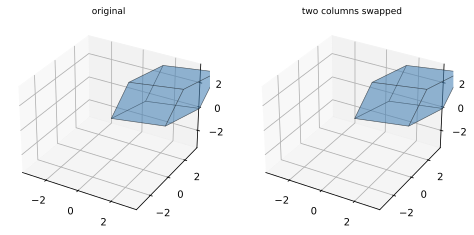

In [2]:
#| label: fig-volume
#| cap: "**Signed volume.** The parallelepiped spanned by the columns of a $3\\times 3$ matrix. Swapping two columns leaves the volume unchanged but flips the sign of the determinant, visible here as a mirrored frame of the same size."

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def parallelepiped(a, ax, color, alpha=0.35):
    # a: 3x3 matrix whose COLUMNS are the edges from the origin.
    corners = np.array([a @ np.array([(i >> k) & 1 for k in range(3)], dtype=float)
                        for i in range(8)])
    faces = [[0,1,3,2],[4,5,7,6],[0,1,5,4],[2,3,7,6],[0,2,6,4],[1,3,7,5]]  # <1>
    poly = Poly3DCollection(corners[faces], alpha=alpha, edgecolor='k', linewidth=0.6)
    poly.set_facecolor(color)
    ax.add_collection3d(poly)

a = np.array([[3.0, 1.0, 0.5],
              [0.5, 2.0, 1.0],
              [0.2, 0.5, 2.5]])          # <2> columns are the three edges
b = a[:, [1, 0, 2]]                       # <3> swap the first two columns

fig = plt.figure(figsize=(8, 4))
for ax, M, title in [(fig.add_subplot(121, projection='3d'), a, 'original'),
                     (fig.add_subplot(122, projection='3d'), b, 'two columns swapped')]:
    parallelepiped(M, ax, 'steelblue')
    lim = 3.5
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_title(title, fontsize=9)

sig = np.prod(np.linalg.svd(a, compute_uv=False))
print(f"det(original) = {np.linalg.det(a):+.4f}")
print(f"det(swapped)  = {np.linalg.det(b):+.4f}")
print(f"product of singular values = {sig:.4f}   (magnitude, sign-free)")
plt.show()


`<1>` enumerates the six faces by fixing each of the three coordinate bits of the cube's eight corners. `<2>` assembles the three edge vectors as the columns of $\mathbf A$, matching the column-based definition. `<3>` produces the column swap whose only effect is to negate the determinant: the printed determinants differ only in sign while the product of singular values is unchanged, the antisymmetry lemma rendered in numbers.


In [3]:
import numpy as np
from scipy.linalg import lu

rng = np.random.default_rng(7)
A = rng.normal(size=(6, 6))
B = rng.normal(size=(6, 6))

print(f"det(AB) - det(A)det(B)   = {np.linalg.det(A @ B) - np.linalg.det(A) * np.linalg.det(B):.2e}")
print(f"det(A.T) - det(A)        = {np.linalg.det(A.T) - np.linalg.det(A):.2e}")

ev = np.linalg.eigvals(A)                  # <1> possibly complex
sv = np.linalg.svd(A, compute_uv=False)
print(f"det(A) - prod(eigvals)    = {np.linalg.det(A) - np.prod(ev).real:.2e}")
print(f"|det(A)| - prod(singvals) = {abs(np.linalg.det(A)) - np.prod(sv):.2e}")

P, L, U = lu(A)                            # <2> A = P @ L @ U
sign = np.linalg.det(P)                    # det of a permutation matrix is +-1
print(f"det(A) - sign*prod(diag(U)) = {np.linalg.det(A) - sign * np.prod(np.diag(U)):.2e}")


det(AB) - det(A)det(B)   = 0.00e+00
det(A.T) - det(A)        = 0.00e+00
det(A) - prod(eigvals)    = 1.60e-14
|det(A)| - prod(singvals) = -8.88e-15
det(A) - sign*prod(diag(U)) = -1.78e-15


Each line exercises a different route to the same number, and all residuals sit at machine precision. `<1>` notes that eigenvalues of a real matrix can be complex; their product is still exactly real, equal to $\det\mathbf A$, so only the real part needs checking. `<2>` is the elimination route: `scipy.linalg.lu` returns the pivoting permutation $\mathbf P$ and unit-lower-triangular $\mathbf L$, so $\det\mathbf A=\det\mathbf P\cdot\prod_i u_{ii}$ with $\det\mathbf L=1$ and $\det\mathbf P=\pm1$. The three identities being verified here are the product rule, transpose invariance, and the elimination formula, all three independent of one another.


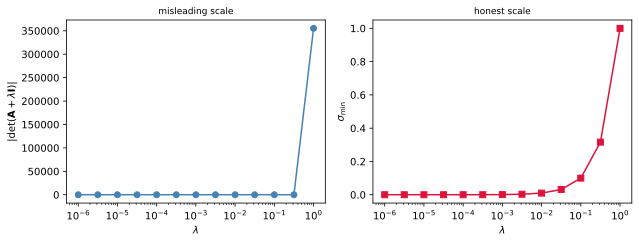

In [4]:
#| label: fig-det-condition
#| cap: "**The determinant misleads near singularity.** Left: the determinant magnitude of $\\mathbf A+\\lambda\\mathbf I$ for a matrix with a zero eigenvalue carries a scale set by the product of the *other* eigenvalues, decoupled from the true gap to singularity. Right: the smallest singular value tracks $\\lambda$ linearly, reporting distance to singularity honestly."

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
n = 20
Q, _ = np.linalg.qr(rng.normal(size=(n, n)))   # <1> random orthogonal
lam = np.zeros(n)
lam[1:] = np.abs(rng.normal(size=n - 1))        # <2> one zero eigenvalue
A = Q @ np.diag(lam) @ Q.T                      # symmetric, eigenvalues = lam

shifts = np.logspace(-6, 0, 13)
dets = [np.linalg.det(A + s * np.eye(n)) for s in shifts]
smins = [np.linalg.svd(A + s * np.eye(n), compute_uv=False)[-1] for s in shifts]

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].semilogx(shifts, np.abs(dets), 'o-', color='steelblue')
ax[0].set_xlabel('$\\lambda$'); ax[0].set_ylabel('$|\\mathrm{det}(\\mathbf{A}+\\lambda\\mathbf{I})|$')
ax[0].set_title('misleading scale', fontsize=9)
ax[1].semilogx(shifts, smins, 's-', color='crimson')
ax[1].set_xlabel('$\\lambda$'); ax[1].set_ylabel('$\\sigma_{\\mathrm{min}}$')
ax[1].set_title('honest scale', fontsize=9)
plt.tight_layout()
plt.show()


The two panels tell opposite stories about the same family of matrices. Because $\det(\mathbf A+\lambda\mathbf I)=\lambda\prod_{i\ge2}(\lambda_i+\lambda)$, the determinant magnitude on the left carries the prefactor $\prod_{i\ge2}\lambda_i\approx 0.13$ (seed 1, $n=20$), which has nothing to do with the planted zero eigenvalue: at $\lambda=10^{-6}$ the matrix is nearly singular, yet its determinant reads only $\approx 1.3\times10^{-7}$, suppressed by the product of the *other* eigenvalues. That dimension-dependent prefactor is exactly what makes $\det$ a poor ruler of distance to singularity. The smallest singular value on the right rises linearly with $\lambda$ and reports the true gap at every point. `<1>` generates an orthogonal $\mathbf Q$ from a QR factorization so that `<2>` can plant eigenvalues by conjugation: $\mathbf A=\mathbf Q\operatorname{diag}(\boldsymbol\lambda)\mathbf Q^{\mathsf T}$ is symmetric with exactly the prescribed spectrum, one zero eigenvalue included. This is the concrete form of the warning that $\det$ confounds the singular direction with all the others.


## Summary

The determinant is the unique alternating multilinear form normalized to $1$ on the standard basis. From that definition everything else flows: it vanishes exactly on dependent columns, it is multiplicative and transpose-invariant, and it evaluates to $\prod_i\lambda_i$ on symmetric matrices and to $\pm\prod_i\sigma_i$ in general. The sign it carries is orientation; the magnitude is volume, which the SVD reports directly. Computationally, elimination computes it in $\mathcal O(n^3)$ via the pivots, but a determinant is usually the wrong tool for measuring ill-conditioning, where the smallest singular value is the honest statistic.
